In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

X_train = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/CA_Moksit/train_input_Z61KlZo.csv")
y_train = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/CA_Moksit/train_output_DzPxaPY.csv")
X_test = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/CA_Moksit/test_input_5qJzHrr.csv")
y_pred_random = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/CA_Moksit/test_output_random.csv")

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

<ipython-input-2-156f88f4fb15>:3: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_train = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/CA_Moksit/train_input_Z61KlZo.csv")
<ipython-input-2-156f88f4fb15>:5: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_test = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/CA_Moksit/test_input_5qJzHrr.csv")


Train: (383610, 374)
Test: (95852, 374)


In [3]:
from sklearn.model_selection import train_test_split

X_train_train, X_train_test, y_train_train, y_train_test = train_test_split(X_train, y_train, test_size=X_test.shape[0], random_state=42)

In [4]:
from sklearn.metrics import root_mean_squared_error

def rmse(y1, y2):
    return round(root_mean_squared_error(y1['CHARGE'], y2['CHARGE']), 2)

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion(pred, y_train_test=y_train_test):
  target = 'CHARGE'
  y_test_target = y_train_test[[target]]
  y_test_binary = (y_test_target != 0).astype(int)

  cm = confusion_matrix(y_test_binary, binary_preds)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Zero", "Non-Zero"])
  disp.plot(cmap=plt.cm.Blues)
  plt.title("Confusion Matrix")
  plt.show()

# Preprocessing

In [6]:
# X_train_train_clean, X_train_test_clean = preprocessing(X_train_train, X_train_test)

# X_train_train_clean.to_csv('Data/X_train_train_clean.csv')
# X_train_test_clean.to_csv('Data/X_train_test_clean.csv')

import pandas as pd

X_train_train_clean = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/CA_Moksit/X_train_train_clean.csv', index_col='ID')
X_train_test_clean = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/CA_Moksit/X_train_test_clean.csv', index_col='ID')

In [7]:
y_train_train = y_train_train.set_index('ID').copy()
y_train_test = y_train_test.set_index('ID').copy()

target = 'CHARGE'
y_train_target = y_train_train[[target]]
y_train_binary = (y_train_target != 0).astype(int)

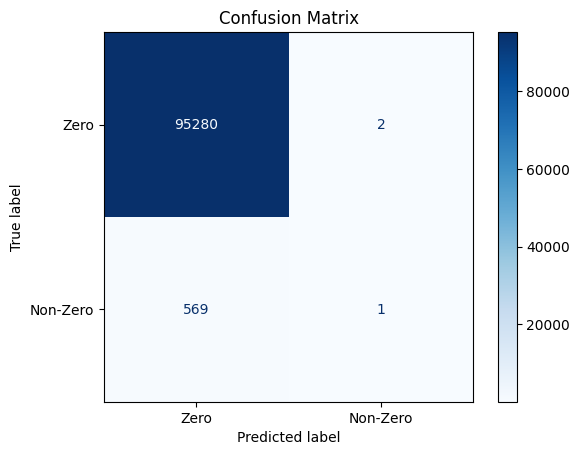

In [8]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train_train_clean, y_train_binary)
binary_preds = clf.predict(X_train_test_clean)

plot_confusion(binary_preds)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


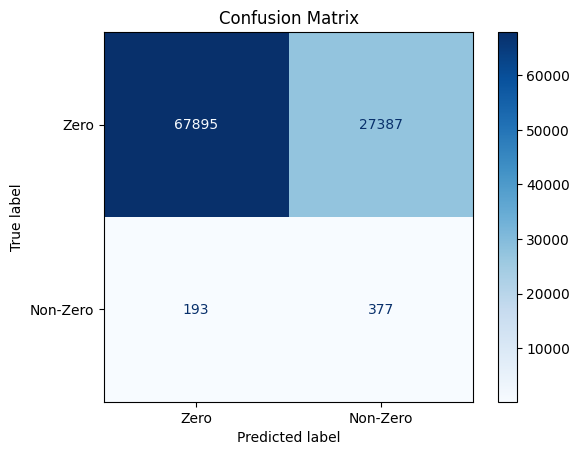

In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', random_state=42),
)
clf.fit(X_train_train_clean, y_train_binary.values.ravel())
binary_preds = clf.predict(X_train_test_clean)

plot_confusion(binary_preds)

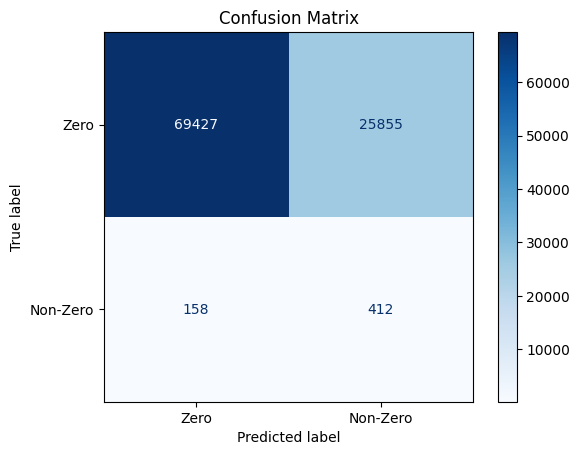

In [8]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

hgb = HistGradientBoostingClassifier(
    random_state=42,
    max_depth=5,
)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_binary.values.ravel())
hgb.fit(X_train_train_clean, y_train_binary.values.ravel(), sample_weight=sample_weights)
binary_preds = hgb.predict(X_train_test_clean)

plot_confusion(binary_preds)

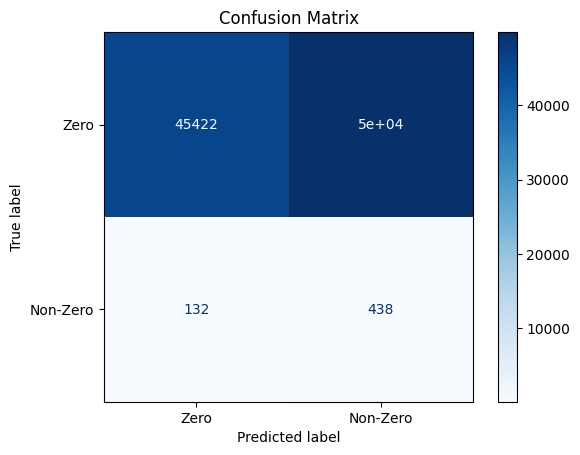

In [12]:
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

nb_pipeline = make_pipeline(
    StandardScaler(),
    GaussianNB(priors=[0.99, 0.01]),
)

nb_pipeline.fit(X_train_train_clean, y_train_binary.values.ravel())
binary_preds = nb_pipeline.predict(X_train_test_clean)

plot_confusion(binary_preds)

<ipython-input-20-fba6f0ca4740>:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  scale_weight = float((y_train_binary == 0).sum() / (y_train_binary == 1).sum())


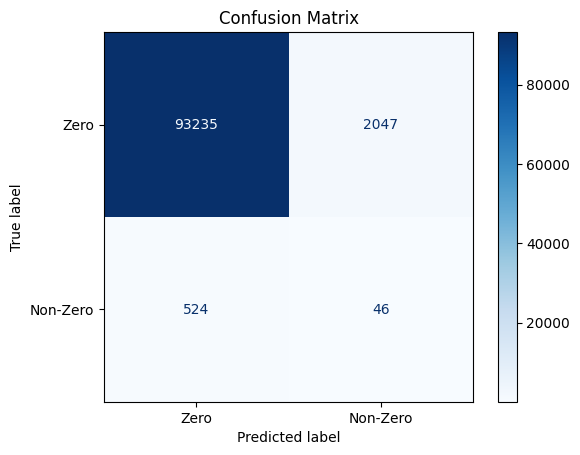

In [20]:
from catboost import CatBoostClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

scale_weight = float((y_train_binary == 0).sum() / (y_train_binary == 1).sum())

cat_pipeline = make_pipeline(
    StandardScaler(),
    CatBoostClassifier(
        scale_pos_weight=scale_weight,
        verbose=0,
        random_seed=42
    )
)
cat_pipeline.fit(X_train_train_clean, y_train_binary.values.ravel())
binary_preds = cat_pipeline.predict(X_train_test_clean)

plot_confusion(binary_preds)

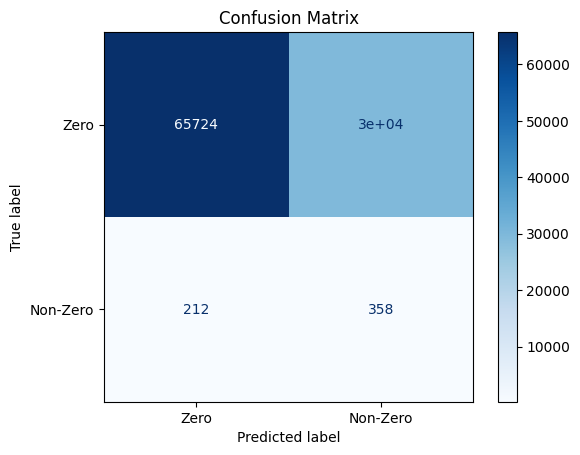

In [22]:
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

sgd_pipeline = make_pipeline(
    StandardScaler(),
    SGDClassifier(
        loss='log_loss',
        class_weight='balanced',
        random_state=42
    )
)
sgd_pipeline.fit(X_train_train_clean, y_train_binary.values.ravel())
binary_preds = sgd_pipeline.predict(X_train_test_clean)

plot_confusion(binary_preds)

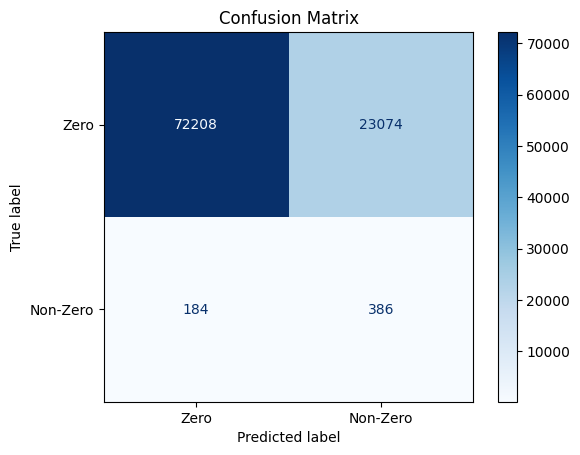

In [23]:
from sklearn.ensemble import HistGradientBoostingClassifier
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.pipeline import make_pipeline

bag_clf = BalancedBaggingClassifier(
        estimator=HistGradientBoostingClassifier(random_state=42, max_depth=5),
        random_state=42,
        n_jobs=2,
    )
bag_clf.fit(X_train_train_clean, y_train_binary.values.ravel())
binary_preds = bag_clf.predict(X_train_test_clean)

plot_confusion(binary_preds)

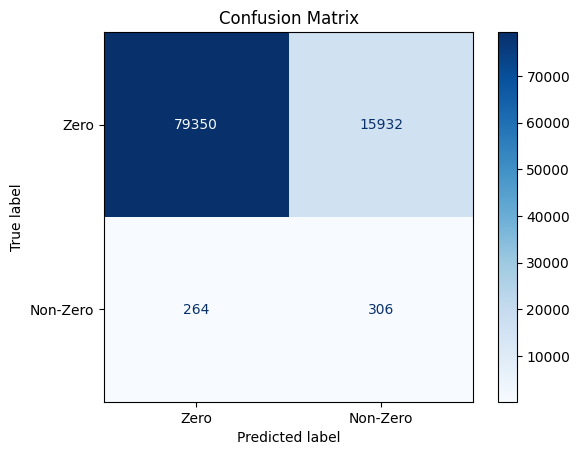

In [25]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.pipeline import make_pipeline

bag_clf = BalancedRandomForestClassifier(
        random_state=42,
    )
bag_clf.fit(X_train_train_clean, y_train_binary.values.ravel())
binary_preds = bag_clf.predict(X_train_test_clean)

plot_confusion(binary_preds)

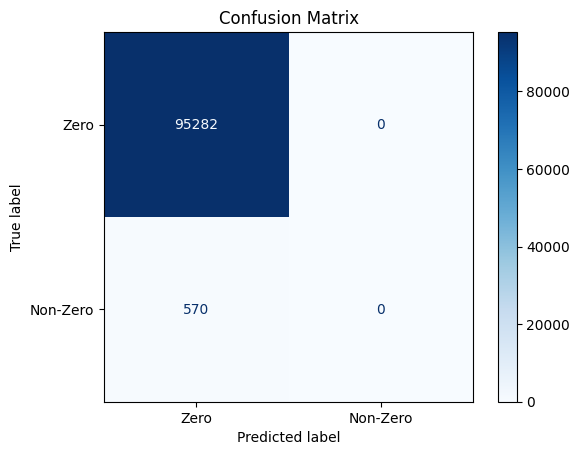

In [26]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ada_pipeline = make_pipeline(
    StandardScaler(),
    AdaBoostClassifier(
        random_state=42
    )
)
ada_pipeline.fit(X_train_train_clean, y_train_binary.values.ravel())
binary_preds = ada_pipeline.predict(X_train_test_clean)

plot_confusion(binary_preds)

<ipython-input-27-b31c991acc03>:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  scale_weight = float((y_train_binary == 0).sum() / (y_train_binary == 1).sum())
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 1788, number of negative: 285970
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.578157 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3475
[LightGBM] [Info] Number of data points in the train set: 287758, number of used features: 371
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.006214 -> initscore=-5.074789
[LightGBM] [Info] Start training from score -5.074789


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


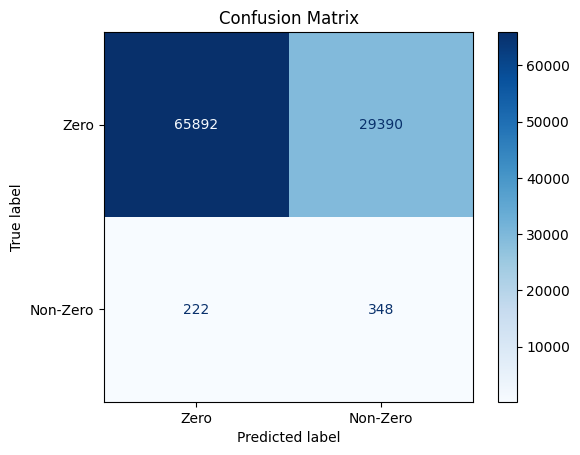

In [27]:
from lightgbm import LGBMClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

scale_weight = float((y_train_binary == 0).sum() / (y_train_binary == 1).sum())
lgbm_pipeline = make_pipeline(
    StandardScaler(),
    LGBMClassifier(
        scale_pos_weight=scale_weight,
        random_state=42
    )
)
lgbm_pipeline.fit(X_train_train_clean, y_train_binary.values.ravel())
binary_preds = lgbm_pipeline.predict(X_train_test_clean)

plot_confusion(binary_preds)

/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


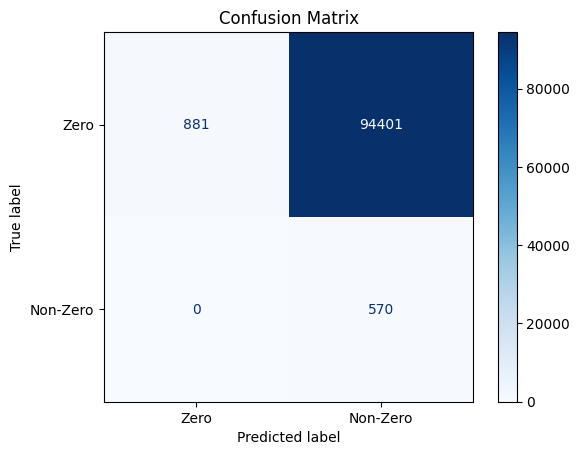

In [8]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

qda_pipeline = make_pipeline(
    StandardScaler(),
    QuadraticDiscriminantAnalysis()
)
qda_pipeline.fit(X_train_train_clean, y_train_binary.values.ravel())
binary_preds = qda_pipeline.predict(X_train_test_clean)

plot_confusion(binary_preds)

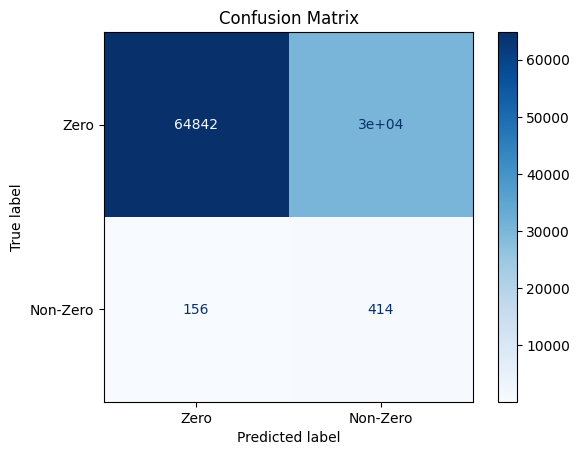

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model = RandomForestClassifier(
    class_weight='balanced',
    max_depth=5,
    random_state=42,
)
model.fit(X_train_train_clean, y_train_binary.values.ravel())
binary_preds = model.predict(X_train_test_clean)

plot_confusion(binary_preds)

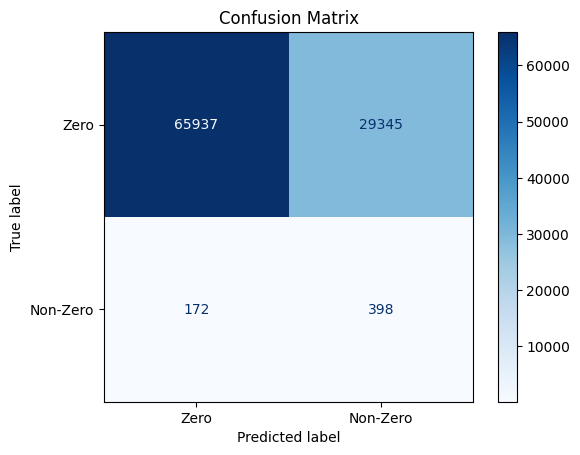

In [12]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model = make_pipeline(
    StandardScaler(),
    LinearDiscriminantAnalysis(n_components=1),
    RandomForestClassifier(
        class_weight='balanced',
        max_depth=5,
        random_state=42
    )
)
model.fit(X_train_train_clean, y_train_binary.values.ravel())
binary_preds = model.predict(X_train_test_clean)

plot_confusion(binary_preds)

<ipython-input-10-243543d7b251>:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  scale_weight = float((y_train_binary == 0).sum() / (y_train_binary == 1).sum())


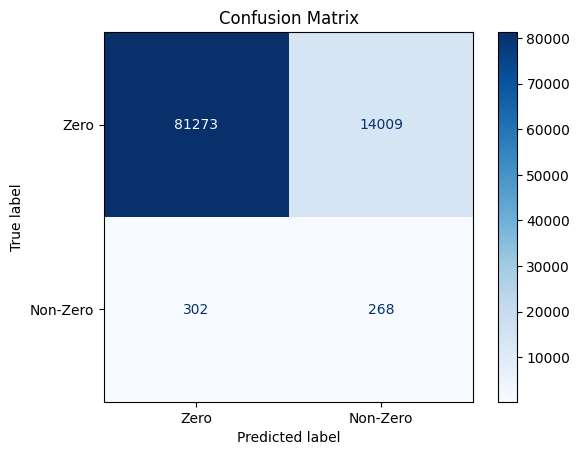

In [10]:
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

scale_weight = float((y_train_binary == 0).sum() / (y_train_binary == 1).sum())
xgb_pipeline = make_pipeline(
    StandardScaler(),
    XGBClassifier(
        scale_pos_weight=scale_weight,
        random_state=42,
        max_depth=5,
    ),
)

xgb_pipeline.fit(X_train_train_clean, y_train_binary.values.ravel())
binary_preds = xgb_pipeline.predict(X_train_test_clean)

plot_confusion(binary_preds)

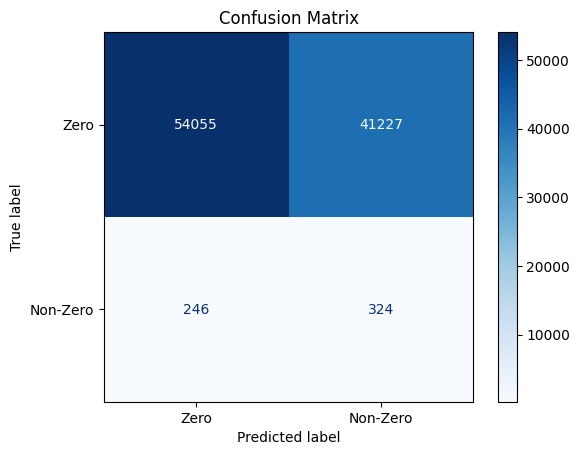

In [11]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

bnb_pipeline = make_pipeline(
    StandardScaler(),
    BernoulliNB(),
)
bnb_pipeline.fit(X_train_train_clean, y_train_binary.values.ravel())
binary_preds = bnb_pipeline.predict(X_train_test_clean)

plot_confusion(binary_preds)

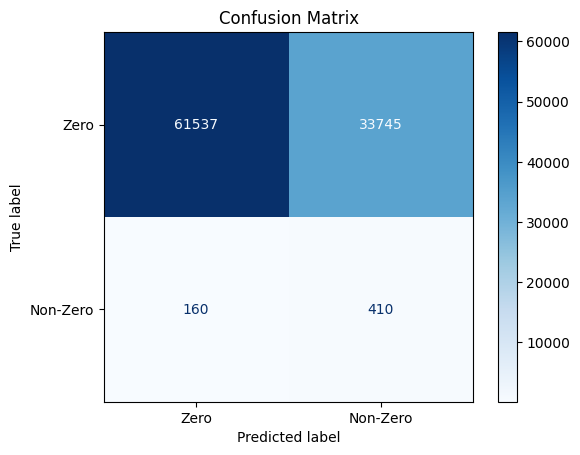

In [14]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

etc_pipeline = make_pipeline(
    StandardScaler(),
    ExtraTreesClassifier(
        max_depth=5,
        class_weight='balanced',
        random_state=42
    )
)
etc_pipeline.fit(X_train_train_clean, y_train_binary.values.ravel())
binary_preds = etc_pipeline.predict(X_train_test_clean)

plot_confusion(binary_preds)

# Ideas

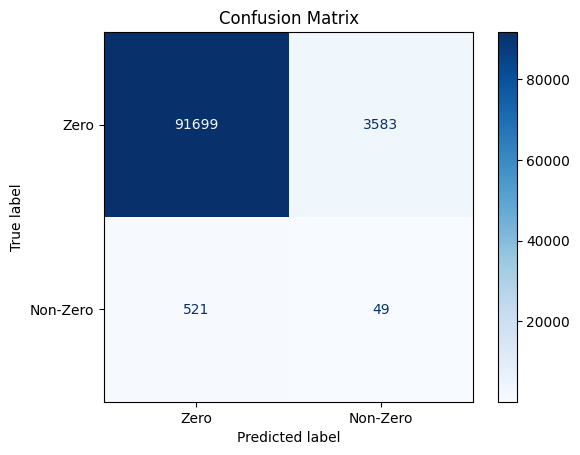

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline

knn_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))
])
knn_pipeline.fit(X_train_train_clean, y_train_binary.values.ravel())
binary_preds = knn_pipeline.predict(X_train_test_clean)

plot_confusion(binary_preds)
# long

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


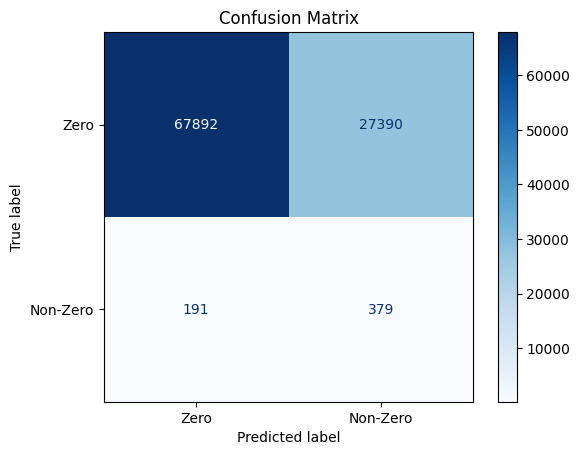

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

logreg_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        l1_ratio=0.5,
        class_weight='balanced',
        random_state=42
    )
)
logreg_pipeline.fit(X_train_train_clean, y_train_binary.values.ravel())
binary_preds = logreg_pipeline.predict(X_train_test_clean)

plot_confusion(binary_preds)
# long

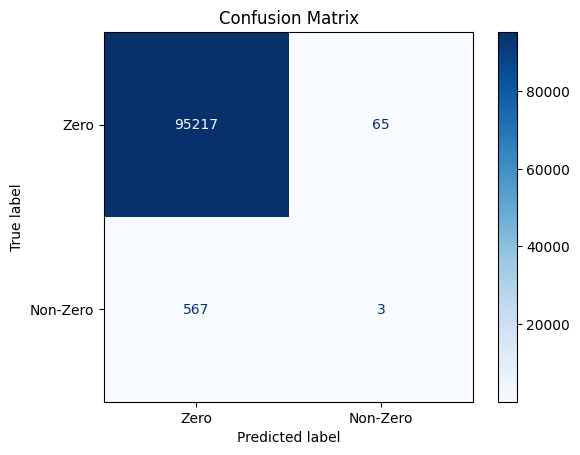

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

knn_pipeline = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',
    )
)

knn_pipeline.fit(X_train_train_clean, y_train_binary.values.ravel())
binary_preds = knn_pipeline.predict(X_train_test_clean)

plot_confusion(binary_preds)
# long

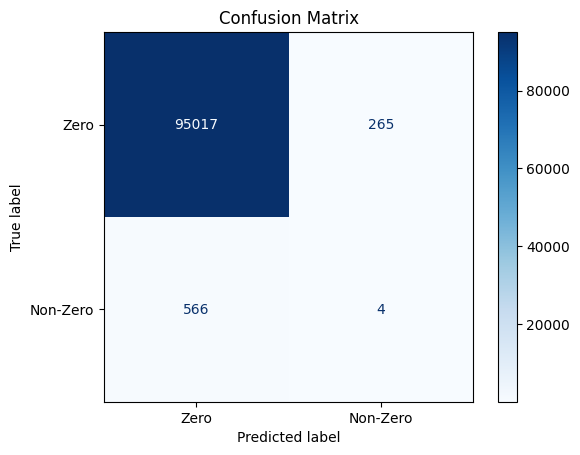

In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

mlp_pipeline = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        random_state=42
    )
)
mlp_pipeline.fit(X_train_train_clean, y_train_binary.values.ravel())
binary_preds = mlp_pipeline.predict(X_train_test_clean)

plot_confusion(binary_preds)
# long

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

svm_pipeline = make_pipeline(
    StandardScaler(),
    SVC(
        class_weight='balanced',
        kernel='rbf',  # 'linear', 'poly', 'rbf
        random_state=42
    )
)
svm_pipeline.fit(X_train_train_clean, y_train_binary.values.ravel())
binary_preds = svm_pipeline.predict(X_train_test_clean)

plot_confusion(binary_preds)
# long